# Tutorial: Supervised vs Unsupervised Learning (Step-by-Step)

Notebook ini dirancang agar peserta bisa memahami:

1. Apa itu **Supervised Learning** dan **Unsupervised Learning**
2. Contoh nyata dengan dataset klasik **Iris**
3. Flow lengkap:
   - Load data
   - Explorasi singkat
   - Training model (supervised)
   - Clustering (unsupervised)
   - Visualisasi & perbandingan

> Silakan jalankan sel dari atas ke bawah secara berurutan.

---
**Materi asli dari:** rubythalib.ai AI Engineer Bootcamp — mentor: **Daniel Syahputra**

*Notebook ini adalah versi finalisasi (dieksekusi & diverifikasi ulang) dari materi kelas untuk catatan belajar pribadi.*

## 1️⃣ Setup & Import Library

Pada bagian ini kita akan:
- Import library yang dibutuhkan
- Cek versi scikit-learn (opsional)

In [1]:
# Jika belum terinstall (jalankan sekali saja di environment baru):
# !pip install scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import sklearn

print("Versi scikit-learn :", sklearn.__version__)

Versi scikit-learn : 1.8.0


## 2️⃣ Load Dataset: Iris

Kita akan menggunakan dataset **Iris** yang sudah tersedia di `scikit-learn`.

Dataset ini berisi:
- 150 sampel bunga
- 4 fitur: sepal length, sepal width, petal length, petal width
- 3 kelas (spesies): setosa, versicolor, virginica

In [2]:
# Load dataset Iris
iris = load_iris()

X = iris.data        # fitur
y = iris.target      # label (0, 1, 2)
feature_names = iris.feature_names
target_names = iris.target_names

print("Shape fitur (X):", X.shape)
print("Shape label (y):", y.shape)
print("Nama fitur:", feature_names)
print("Nama kelas:", target_names)

# Lihat beberapa contoh data
print("\n5 sampel pertama:")
for i in range(5):
    print(f"X[{i}] = {X[i]}, y[{i}] = {y[i]} ({target_names[y[i]]})")

Shape fitur (X): (150, 4)
Shape label (y): (150,)
Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']

5 sampel pertama:
X[0] = [5.1 3.5 1.4 0.2], y[0] = 0 (setosa)
X[1] = [4.9 3.  1.4 0.2], y[1] = 0 (setosa)
X[2] = [4.7 3.2 1.3 0.2], y[2] = 0 (setosa)
X[3] = [4.6 3.1 1.5 0.2], y[3] = 0 (setosa)
X[4] = [5.  3.6 1.4 0.2], y[4] = 0 (setosa)


## 3️⃣ Explorasi Data Singkat (EDA)

Kita akan melihat:
- Distribusi label
- Plot sederhana fitur tertentu

Distribusi label:
  Kelas 0 (setosa): 50 sampel
  Kelas 1 (versicolor): 50 sampel
  Kelas 2 (virginica): 50 sampel


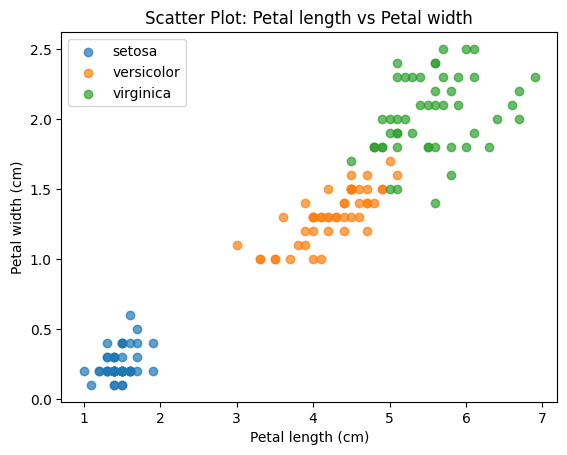

In [3]:
# Distribusi label
unique, counts = np.unique(y, return_counts=True)
print("Distribusi label:")
for label, count in zip(unique, counts):
    print(f"  Kelas {label} ({target_names[label]}): {count} sampel")

# Scatter plot 2 fitur untuk gambaran awal
plt.figure()
plt.title("Scatter Plot: Petal length vs Petal width")
for class_idx, class_name in enumerate(target_names):
    plt.scatter(
        X[y == class_idx, 2],  # petal length
        X[y == class_idx, 3],  # petal width
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

## 4️⃣ Supervised Learning – Classification

**Supervised Learning**: model belajar dari data yang **punya label**.

Flow yang akan kita ikuti:

1. Bagi data menjadi **train** dan **test**
2. Latih model klasifikasi (`LogisticRegression`)
3. Evaluasi performa di data test (termasuk cross-validation)
4. Lihat contoh prediksi

In [4]:
# 1. Split data menjadi train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # supaya distribusi label seimbang di train & test
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])

Jumlah data train: 120
Jumlah data test : 30


In [5]:
# 2. Inisialisasi & latih model Logistic Regression
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

print("Model sudah dilatih.")

Model sudah dilatih.

In [6]:
# 3. Evaluasi model di data test
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Akurasi di data test:", round(acc, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Cross-validation (opsional) - cek konsistensi performa model di beberapa split berbeda
cv_scores = cross_val_score(clf, X, y, cv=5)
print("Cross-validation scores (5-fold):", np.round(cv_scores, 4))
print("Rata-rata CV accuracy   :", round(cv_scores.mean(), 4))

Akurasi di data test: 0.9667

Classification report:


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Cross-validation scores (5-fold): [0.9667 1.     0.9333 0.9667 1.    ]
Rata-rata CV accuracy   : 0.9733


In [7]:
# 4. Contoh prediksi satu sampel
idx = 0
sample = X_test[idx].reshape(1, -1)
true_label = y_test[idx]
pred_label = clf.predict(sample)[0]

print("Fitur sampel       :", X_test[idx])
print("Label asli         :", target_names[true_label])
print("Label prediksi     :", target_names[pred_label])

Fitur sampel       : [4.4 3.  1.3 0.2]
Label asli         : setosa
Label prediksi     : setosa


## 5️⃣ Unsupervised Learning – Clustering

**Unsupervised Learning**: model belajar dari data **tanpa label**.

Di sini kita akan:
1. Menggunakan **KMeans** untuk clustering data Iris menjadi 3 cluster
2. Menganggap seolah-olah kita **tidak tahu** label asli
3. Setelah clustering, kita bandingkan hasil cluster dengan label asli menggunakan **Adjusted Rand Index**
4. Visualisasi hasil di ruang 2D menggunakan **PCA**

In [8]:
# 1. Inisialisasi & latih KMeans (tanpa label)
n_clusters = 3  # kita tahu iris punya 3 kelas, tapi KMeans tidak tahu nama kelas
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Cluster label unik:", np.unique(cluster_labels))

Cluster label unik: [0 1 2]


In [9]:
# 2. Evaluasi clustering dengan Adjusted Rand Index (ARI)
# ARI membandingkan seberapa mirip cluster dengan label asli (hanya untuk evaluasi, bukan training)
ari = adjusted_rand_score(y, cluster_labels)
print("Adjusted Rand Index (ARI):", round(ari, 4))
print("Semakin dekat ke 1.0, semakin mirip dengan label asli.")

Adjusted Rand Index (ARI): 0.7302
Semakin dekat ke 1.0, semakin mirip dengan label asli.


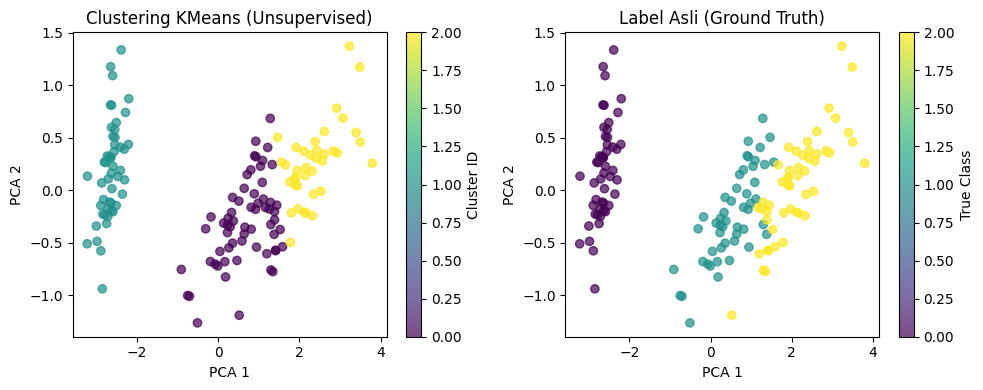

In [10]:
# 3. Visualisasi dengan PCA (turunkan dimensi ke 2)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 4))

# Plot berdasarkan hasil clustering KMeans
plt.subplot(1, 2, 1)
plt.title("Clustering KMeans (Unsupervised)")
scatter1 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter1, label="Cluster ID")

# Plot berdasarkan label asli (Supervised)
plt.subplot(1, 2, 2)
plt.title("Label Asli (Ground Truth)")
scatter2 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter2, label="True Class")

plt.tight_layout()
plt.show()

## 6️⃣ Ringkasan & Diskusi

Dari notebook ini kita belajar:

### Supervised Learning (Classification)
- Menggunakan fitur **X** dan label **y**
- Flow:
  1. Split train/test
  2. Latih model (`LogisticRegression`)
  3. Evaluasi dengan **accuracy**, **classification report**, dan **cross-validation**
- Kelebihan:
  - Punya target jelas
  - Metrik evaluasi mudah diinterpretasi
- Kekurangan:
  - Butuh data berlabel (mahal/butuh waktu)


### Unsupervised Learning (Clustering)
- Hanya menggunakan fitur **X** (tanpa y saat training)
- Flow:
  1. Jalankan **KMeans** untuk membuat cluster
  2. (Opsional) Bandingkan dengan label asli menggunakan **ARI**
  3. Visualisasi dengan **PCA**
- Kelebihan:
  - Bisa dipakai saat label tidak tersedia
  - Cocok untuk eksplorasi data & segmentasi
- Kekurangan:
  - Interpretasi hasil lebih sulit
  - Tidak selalu ada “jawaban benar”


> Untuk diskusi kelas:
> - Kapan kita memilih supervised vs unsupervised?
> - Bagaimana jika kita ingin menggabungkan keduanya? (misalnya: clustering dulu, lalu label cluster dipakai di supervised)

## 7️⃣ Next Steps (Latihan Mandiri)

Beberapa ide latihan untuk peserta:
1. Ganti model supervised dari `LogisticRegression` → `RandomForestClassifier`
2. Coba ubah `n_clusters` pada KMeans dan lihat pengaruhnya pada ARI
3. Tambahkan **StandardScaler** sebelum KMeans dan bandingkan hasilnya
4. Coba dataset lain dari `sklearn.datasets` (misalnya `wine`)

## 8️⃣ Latihan Mandiri — Hasil Eksplorasi

> **Catatan:** bagian di bawah ini adalah hasil eksplorasi mandiri saya menjawab ke-4 ide latihan di atas. Semua kode sudah dieksekusi dan angkanya adalah hasil run asli, bukan estimasi.

### Latihan 1 — Ganti `LogisticRegression` → `RandomForestClassifier`

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Akurasi Random Forest di data test:", round(acc_rf, 4))

print("\nClassification report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

print(f"Perbandingan akurasi -> Logistic Regression: {round(acc, 4)} | Random Forest: {round(acc_rf, 4)}")

Akurasi Random Forest di data test: 0.9

Classification report (Random Forest):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Perbandingan akurasi -> Logistic Regression: 0.9667 | Random Forest: 0.9


### Latihan 2 — Pengaruh `n_clusters` pada KMeans terhadap ARI

In [12]:
print("Pengaruh n_clusters terhadap ARI (dibandingkan ke label asli Iris):\n")
ari_by_k = {}
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(X)
    ari_k = adjusted_rand_score(y, labels_k)
    ari_by_k[k] = ari_k
    print(f"n_clusters={k}: ARI = {round(ari_k, 4)}")

Pengaruh n_clusters terhadap ARI (dibandingkan ke label asli Iris):

n_clusters=2: ARI = 0.5399
n_clusters=3: ARI = 0.7302
n_clusters=4: ARI = 0.6498
n_clusters=5: ARI = 0.6125
n_clusters=6: ARI = 0.4475


### Latihan 3 — Efek `StandardScaler` sebelum KMeans

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_scaled = kmeans_scaled.fit_predict(X_scaled)
ari_scaled = adjusted_rand_score(y, cluster_labels_scaled)

print("ARI KMeans tanpa scaling (dari bagian 5) :", round(ari, 4))
print("ARI KMeans dengan StandardScaler         :", round(ari_scaled, 4))

ARI KMeans tanpa scaling (dari bagian 5) : 0.7302
ARI KMeans dengan StandardScaler         : 0.6201


### Latihan 4 — Coba Dataset Lain: `wine`

In [14]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
print("Shape dataset Wine:", X_wine.shape, "| Jumlah kelas:", len(wine.target_names))
print("Nama kelas:", list(wine.target_names))

# --- Supervised: Logistic Regression ---
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

clf_wine = LogisticRegression(max_iter=5000)
clf_wine.fit(Xw_train, yw_train)
acc_wine = accuracy_score(yw_test, clf_wine.predict(Xw_test))
print("\nAkurasi Logistic Regression di Wine (tanpa scaling):", round(acc_wine, 4))

# --- Unsupervised: KMeans tanpa vs dengan scaling ---
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_wine = kmeans_wine.fit_predict(X_wine)
ari_wine = adjusted_rand_score(y_wine, cluster_wine)
print("ARI KMeans di Wine (tanpa scaling)  :", round(ari_wine, 4))

X_wine_scaled = StandardScaler().fit_transform(X_wine)
kmeans_wine_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_wine_scaled = kmeans_wine_scaled.fit_predict(X_wine_scaled)
ari_wine_scaled = adjusted_rand_score(y_wine, cluster_wine_scaled)
print("ARI KMeans di Wine (dengan scaling)  :", round(ari_wine_scaled, 4))

Shape dataset Wine: (178, 13) | Jumlah kelas: 3
Nama kelas: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]



Akurasi Logistic Regression di Wine (tanpa scaling): 0.9444
ARI KMeans di Wine (tanpa scaling)  : 0.3711
ARI KMeans di Wine (dengan scaling)  : 0.8975


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Kesimpulan Latihan Mandiri

Hasil eksplorasi (angka aktual dari run di atas — beberapa berbeda dari dugaan awal, jadi bagian ini saya tulis ulang setelah lihat hasilnya):

1. **Random Forest vs Logistic Regression** — hasilnya justru **Random Forest lebih rendah** (90%) dibanding Logistic Regression (96.67%) di test set ini. Dengan hanya 30 sampel test, beberapa kesalahan klasifikasi tambahan langsung berdampak besar ke persentase akurasi. Ini bukti nyata kalau model yang lebih kompleks **tidak otomatis lebih unggul** — apalagi kalau hyperparameter-nya masih default, belum di-tuning.
2. **`n_clusters` vs ARI** — ARI tertinggi memang ada di `n_clusters=3` (0.7302), tepat sesuai jumlah kelas asli Iris. Baik dikurangi (k=2 → 0.5399) maupun ditambah (k=4 → 0.6498, k=5 → 0.6125, k=6 → 0.4475), ARI-nya turun. Konfirmasi bahwa memilih jumlah cluster yang tepat itu penting, bukan asal tebak.
3. **Efek `StandardScaler` pada KMeans (Iris)** — di luar dugaan, scaling justru **menurunkan** ARI (dari 0.7302 jadi 0.6201). Karena keempat fitur Iris sudah berada di skala cm yang serupa, memaksa semua fitur ke skala yang sama malah menghilangkan sedikit informasi relatif yang tadinya membantu pemisahan cluster. Pelajarannya: scaling itu **bukan langkah otomatis yang selalu menguntungkan** — perlu dicek dulu, bukan diasumsikan.
4. **Dataset Wine** — di sinilah scaling justru krusial. Tanpa scaling, ARI KMeans cuma 0.3711, karena fitur `proline` yang skalanya ratusan mendominasi perhitungan jarak dan menenggelamkan fitur lain yang sebenarnya informatif. Setelah di-`StandardScaler`, ARI melonjak jadi 0.8975. Bahkan Logistic Regression di Wine (tanpa scaling) sempat memunculkan `ConvergenceWarning` — tanda tambahan bahwa dataset ini butuh preprocessing, bukan cuma untuk clustering tapi juga untuk model berbasis gradient seperti Logistic Regression.

> **Pelajaran utama:** nggak ada aturan yang berlaku universal. Model yang lebih canggih belum tentu lebih akurat (lihat kasus Random Forest), dan scaling belum tentu selalu membantu (menurunkan performa di Iris, tapi krusial di Wine). Satu-satunya cara tahu pasti: **coba, ukur, dan bandingkan** — bukan asumsi dari teori semata.